In [ ]:
# LIBRARIES

from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain.chains import create_sql_query_chain

from langgraph.graph import END, StateGraph

import os
import yaml
import re
from pprint import pprint
from typing import List, TypedDict

from IPython.display import Image

In [ ]:
# AI SETUP

os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

OPENAI_LLM = ChatOpenAI(
    model = "gpt-4o-mini"
)

llm = OPENAI_LLM

In [ ]:
# SQL DATABASE SETUP

PATH_DB = "sqlite:///database/leads_scored.db"

In [ ]:
# HELPER FUNCTIONS

def extract_sql_code(text):
    sql_code_match = re.search(r'```sql(.*?)```', text, re.DOTALL)
    sql_code_match_2 = re.search(r"SQLQuery:\s*(.*)", text)
    if sql_code_match:
        sql_code = sql_code_match.group(1).strip()
        return sql_code
    if sql_code_match_2:
        sql_code = sql_code_match_2.group(1).strip()
        return sql_code
    else:
        sql_code_match = re.search(r"sql(.*?)'", text, re.DOTALL)
        if sql_code_match:
            sql_code = sql_code_match.group(1).strip()
            return sql_code
        else:
            return None

In [ ]:
db = SQLDatabase.from_uri(PATH_DB)

sql_generator = create_sql_query_chain(
    llm = llm,
    db = db,
    k = 1e7,
)

sql_generator

RunnableAssign(mapper={
  input: RunnableLambda(...),
  table_info: RunnableLambda(...)
})
| RunnableLambda(lambda x: {k: v for (k, v) in x.items() if k not in ('question', 'table_names_to_use')})
| PromptTemplate(input_variables=['input', 'table_info'], partial_variables={'top_k': '10000000.0'}, template='You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.\nUnless the user specifies in the question a specific number of examples to obtain, query for at most {top_k} results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.\nNever query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.\nPay attention to use only the column names you can see in the tabl

In [ ]:
response = sql_generator.invoke({"question": "which 10 customers have the highest p1 probability of purchase?"})

In [ ]:
pprint(extract_sql_code(response))

('SELECT "user_full_name", "user_email", "p1" \n'
 'FROM leads_scored \n'
 'ORDER BY "p1" DESC \n'
 'LIMIT 10;')


In [ ]:
response = sql_generator.invoke({"question": "what tables are in the database?"})

In [ ]:
pprint(extract_sql_code(response))

"SELECT name FROM sqlite_master WHERE type='table';"


In [ ]:
# * LANGGRAPH
class GraphState(TypedDict):
    """
    Represents the state of our graph.
    """
    question: str
    sql_query : str

In [ ]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("question")
    
    # Generate SQL
    sql_query = sql_generator.invoke({"question": question})
    
    # Extract SQL code
    sql_query = extract_sql_code(sql_query)
    
    return {"sql_query": sql_query}

In [ ]:
def state_printer(state):
    """print the state"""
    print("---STATE PRINTER---")
    print(f"question: {state['question']}")
    pprint(f"SQL Query: {state['sql_query']}")

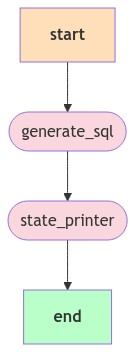

In [ ]:
# * WORKFLOW DAG

workflow = StateGraph(GraphState)

workflow.add_node("generate_sql", generate_sql)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()

Image(app.get_graph().draw_mermaid_png())

In [ ]:
# * TESTING

QUESTION = """
Which 10 customers have the highest p1 probability of purchase?
"""

inputs = {"question": QUESTION}
for s in app.stream(inputs):
    print(s)

---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "user_full_name", "user_email", "p1" \nFROM leads_scored \nORDER BY "p1" DESC \nLIMIT 10;'}}
---STATE PRINTER---
question: 
Which 10 customers have the highest p1 probability of purchase?

('SQL Query: SELECT "user_full_name", "user_email", "p1" \n'
 'FROM leads_scored \n'
 'ORDER BY "p1" DESC \n'
 'LIMIT 10;')


In [ ]:
QUESTION = """
What are the first five rows of each table?
"""

inputs = {"question": QUESTION}
for s in app.stream(inputs):
    print(s)

---GENERATE SQL---
{'generate_sql': {'sql_query': '-- Query to fetch the first five rows from each table\n\n-- Leads table\nSELECT "mailchimp_id", "user_full_name", "user_email", "member_rating", "optin_time", "country_code", "made_purchase", "optin_days", "email_provider"\nFROM leads\nLIMIT 5;\n\n-- Leads Scored table\nSELECT "mailchimp_id", "user_full_name", "user_email", "member_rating", "optin_time", "country_code", "made_purchase", "optin_days", "email_provider", "predict", "p0", "p1"\nFROM leads_scored\nLIMIT 5;\n\n-- Message Store table\nSELECT "id", "session_id", "message"\nFROM message_store\nLIMIT 5;\n\n-- Products table\nSELECT "product_id", "description", "suggested_price"\nFROM products\nLIMIT 5;\n\n-- Transactions table\nSELECT "transaction_id", "purchased_at", "user_full_name", "user_email", "charge_country", "product_id"\nFROM transactions\nLIMIT 5;'}}
---STATE PRINTER---
question: 
What are the first five rows of each table?

('SQL Query: -- Query to fetch the first fi

In [ ]:
QUESTION = """
Extract the transactions table. Return all rows.
"""

inputs = {"question": QUESTION}
for s in app.stream(inputs):
    print(s)

---GENERATE SQL---
{'generate_sql': {'sql_query': 'SELECT "transaction_id", "purchased_at", "user_full_name", "user_email", "charge_country", "product_id" FROM transactions LIMIT 10000000;'}}
---STATE PRINTER---
question: 
Extract the transactions table. Return all rows.

('SQL Query: SELECT "transaction_id", "purchased_at", "user_full_name", '
 '"user_email", "charge_country", "product_id" FROM transactions LIMIT '
 '10000000;')


In [ ]:
QUESTION = """
What are the total sales by month-year?
"""

inputs = {"question": QUESTION}
for s in app.stream(inputs):
    print(s)

---GENERATE SQL---
{'generate_sql': {'sql_query': 'SQLQuery: SELECT strftime(\'%Y-%m\', "purchased_at") AS "month_year", COUNT("transaction_id") AS "total_sales" FROM "transactions" GROUP BY "month_year" ORDER BY "month_year"'}}
---STATE PRINTER---
question: 
What are the total sales by month-year?

('SQL Query: SQLQuery: SELECT strftime(\'%Y-%m\', "purchased_at") AS '
 '"month_year", COUNT("transaction_id") AS "total_sales" FROM "transactions" '
 'GROUP BY "month_year" ORDER BY "month_year"')
